Our expectation with the original LEMBAS is as follows:
1) It cannot handle multiple cell types
2) It cannot account for the dispersion within a cluster at single-cell resolution, and will output the centroid of a cluster instead.

Next, we want to see whether scLEMBAS can capture single-cell resolution data.

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainCat
from scLEMBAS.plotting import plot_embedding
from scLEMBAS.preprocess import embed_tf_activity

<Figure size 100x100 with 0 Axes>

In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)

In [3]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

# Load and Parse Input Signaling Network

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [5]:
sn_ppis = parse_network.load_network('omnipath', organism = 'mouse', static = True)

sn_ppis = parse_network.correct_network(sn_ppis = sn_ppis,
                                        source_label = source_label, target_label = target_label,
                                        stimulation_label = stimulation_label, inhibition_label = inhibition_label)

sn_ppis = parse_network.extract_network(sn_ppis, curation_effort_thresh = 5, n_references_thresh = 3,
                                        resources = ['HuRI','IntAct','KEGG-MEDICUS','NetPath','Reactome_SignaLink3','SPIKE','SignaLink3','SIGNOR', 
                                                'Baccin2019', 'Ramilowski2015', 'Reactome_LRdb', 'UniProt_LRdb', 'CellChatDB', 'CellPhoneDB', 'connectomeDB2020', 'scConnect'], 
                                        source_label = source_label, target_label = target_label,
                                        drop_self = True, verbose = True)



The thresholds filtered 66381  of 75185 interactions
The resources filtered 1940  of 8804 interactions


Filter for nodes that fall in paths between ligands and receptors (fully connected network):

In [6]:
tf_labels = tf_adata.var.index.unique().tolist()

ligand_labels = tf_adata.obs['sample'].unique().tolist()
ligand_labels = [(l[0] + l[1:].lower()).replace('-', '') for l in ligand_labels] # mouse naming convention

# filter for paths b/w ligand and tf
fn_1, _ = parse_network.create_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'shortest')
fn_2, _ = parse_network.create_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'connected')
# of the methods to identify paths, retain the one that has the most interactions
if fn_1.shape[0] > fn_2.shape[0]:
    sn_ppis = fn_1
else:
    sn_ppis = fn_2

del fn_1, fn_2

100%|████████████████████████████████████| 8432/8432 [00:00<00:00, 22760.47it/s]


Finally, let's format the network as needed for input to building the model:

In [7]:
sn_ppis = parse_network.format_network(sn_ppis, weight_label, stimulation_label, inhibition_label) 
# sn_ppis.to_csv(os.path.join(data_path, 'processed', 'ID_input_network.csv'))

In [8]:
print('The signaling network contains {} interactions'.format(sn_ppis.shape[0]))
sn_ppis[[source_label, target_label, weight_label, stimulation_label, inhibition_label]].head()

The signaling network contains 4583 interactions


,source_genesymbol,target_genesymbol,mode_of_action,consensus_stimulation,consensus_inhibition
145,Mapk14,Mapkapk2,1.0,True,False
146,Mapkapk2,Mapk14,0.1,False,False
152,Epor,Jak2,0.1,False,False
153,Jak2,Epor,1.0,True,False
159,Numb,Notch1,-1.0,False,True


The interactions include the following input ligands:

In [9]:
all_nodes = sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()
input_ligands_available = sorted(set(ligand_labels).intersection(all_nodes))
print(*input_ligands_available, sep = ', ')

Egf, Gdnf, Hgf, Ifng, Il10, Il11, Il13, Il15, Il1a, Il1b, Il2, Il21, Il4, Il5, Il6, Il7, Il9, Lif, Osm, Tslp


# Explore performance on TF activity

In [10]:
group_label = 'TF_clusters' # ordered cateogry in obs

## Scenario 3:

In [11]:
model_no = 3

The simplest scenario is:
- 2 cell type
- 1 ligand
- Binary ligand exposure (0 or 1)
- Exposure leads to distinct clusters in TF activity space

For now, we simply use visualization to identify the most distinct clusters:

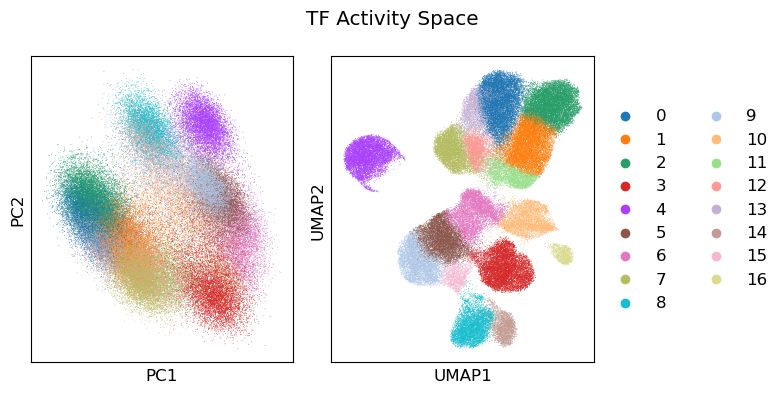

In [12]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(tf_adata, color='TF_clusters', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(tf_adata, color='TF_clusters', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('TF Activity Space')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, we choose clusters 2, 3, 4, and 5:

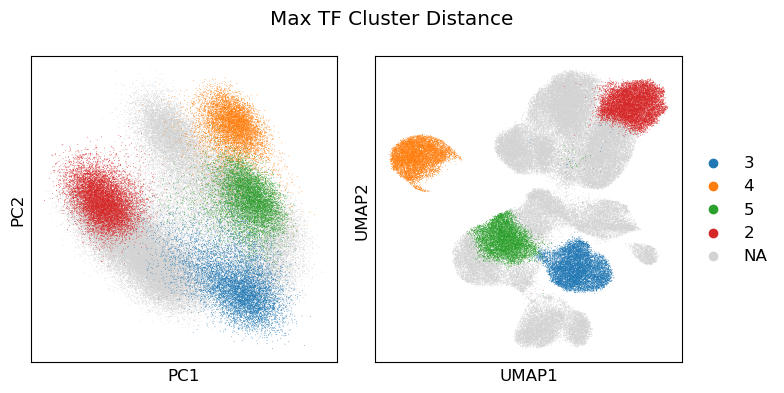

In [13]:
max_clusters = ['3', '4', '5', '2']
viz_adata = tf_adata.copy()
viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
                                                       categories = max_clusters, 
                                                       ordered = True)
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(viz_adata, color=group_label + '_color', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(viz_adata, color=group_label + '_color', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('Max TF Cluster Distance')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, let's say that cluster 9 is unstimulated, and cluster 15 is stimulated. 

In [12]:
max_clusters = ['3', '4', '5', '2']

In [13]:
np.random.seed(seed)
selected_ligand = np.random.choice(input_ligands_available, 1)[0]
print('The selected ligand is: ' + selected_ligand)

subset_tf = tf_adata[tf_adata.obs.TF_clusters.isin(max_clusters)]
subset_tf.obs.TF_clusters.value_counts()

The selected ligand is: Il5


TF_clusters
2    9687
3    8522
4    7336
5    6970
Name: count, dtype: int64

For now, for speed, let's subset so that there are a smaller number of "samples" per condition:

In [14]:
sample_size = int(2.5e3)

barcodes = []
for cluster_label in subset_tf.obs.TF_clusters.unique():
    bc = subset_tf.obs[subset_tf.obs.TF_clusters == cluster_label].index
    np.random.seed(seed)
    barcodes += list(np.random.choice(bc, sample_size, replace = False))
subset_tf = subset_tf[barcodes, :]
subset_tf.obs.TF_clusters.value_counts()

TF_clusters
2    2500
3    2500
4    2500
5    2500
Name: count, dtype: int64

Next, let's initialize the model. 

Let's say clusters 4 and 5 are unstimulated, and 3 and 2 are stimulated
We assign clusters 3 and 4 as cell Type A, and 5 and 2 as cell type B.

In [15]:
ligand_input = pd.DataFrame(subset_tf.obs.TF_clusters.map({'4': 0, '5': 0, '3': 1, '2': 1}))
ligand_input.columns = [selected_ligand]


covariates = pd.DataFrame(subset_tf.obs.TF_clusters.map({'3': 'A', '4': 'A',
                                                        '5': 'B', '2': 'B'}))
covariates.columns = ['celltype']


tf_output = pd.DataFrame(subset_tf.X, index = subset_tf.obs.index, columns = subset_tf.var.index)

In [16]:
subset_tf.obs = pd.concat([covariates, ligand_input, pd.DataFrame({'TF_clusters': subset_tf.obs.TF_clusters})], axis = 1)

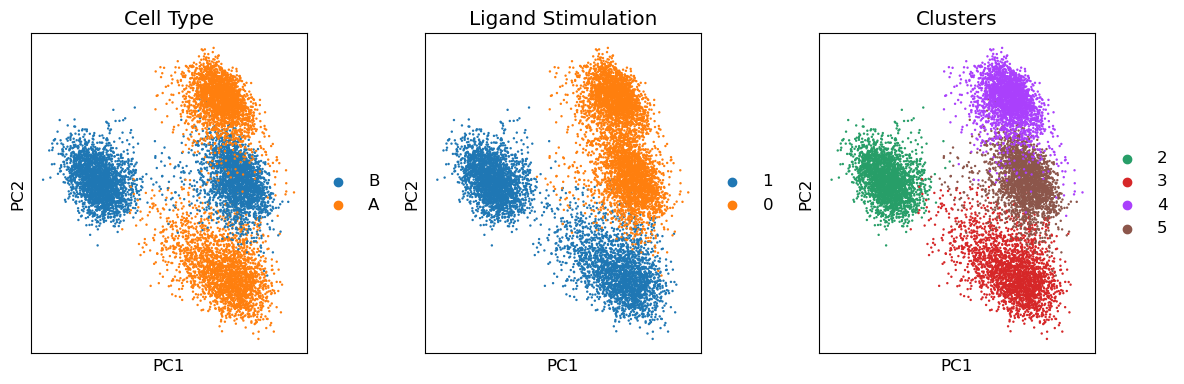

In [19]:
viz_adata = subset_tf.copy()
for col in viz_adata.obs.columns:
    viz_adata.obs[col] = pd.Categorical(viz_adata.obs[col],
                                        categories = viz_adata.obs[col].unique())


fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))
sc.pl.pca(viz_adata, color='celltype', ax = ax[0], show = False)
ax[0].set_title('Cell Type')

sc.pl.pca(viz_adata, color=selected_ligand, ax = ax[1], show = False)
ax[1].set_title('Ligand Stimulation')

sc.pl.pca(viz_adata, color='TF_clusters', ax = ax[2], show = False)
ax[2].set_title('Clusters')


fig.tight_layout()
plt.show()

In [17]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 

# training parameters
lr_params = {'max_epochs': 5000, 'maximum_learning_rate': 2e-3, 'minimum_learning_rate': 2e-4,
                 'lr_restart_epoch': 1000, 'reset_optimizer_epoch': 200, 
                'lr_decay': 0.9, 'lr_restart_factor': 1, 'warmup_epochs': 500}

other_params = {'train_batch_size': 512, 'test_batch_size': 512, 'validation_batch_size': 512, 
                    'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}

regularization_params = {'input_lambda_L2': 1e-6, 'hidden_state_lambda_L2': 1e-6, 'bias_lambda_L2': 1e-6, 
                             'output_lambda_L2': 1e-6, 
                         'discriminator_lambda_L2': 1e-5,
                         'moa_lambda_L1': 0.1, #'ligand_lambda_L2': 1e-5, 
                         'uniform_lambda_L2': 1e-4,  
                         'uniform_max': (1/1.2), 
                         'spectral_loss_factor': 1e-5}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.ReLU,
              'vae_n_hidden_nodes': [1024, 768, 512], 
              'vae_var_min': 1e-4}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}
target_spectral_radius = 0.8

In [22]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = tf_adata.to_df(), 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

# Start dev

In [19]:
# scl initialization inputs
net = sn_ppis
X_in = ligand_input
y_out = tf_output
covariates = subset_tf.obs
categorical_covariate_keys = ['celltype']
projection_amplitude_in = projection_amplitude_in
projection_amplitude_out = projection_amplitude_out
weight_label = weight_label
source_label = source_label
target_label = target_label
bionet_params = bionet_params
dtype = torch.float32
device = device
seed = seed
ban_list = []

In [20]:
# initialization prior to bionet
from scLEMBAS.model.scl import *
self = mod

self.dtype = dtype
self.device = device
self.seed = seed
self._gradient_seed_counter = 0
self.projection_amplitude_out = projection_amplitude_out

edge_list, node_labels, edge_MOA = self.parse_network(net, ban_list, weight_label, source_label, target_label)


# filter for nodes in the network, sorting by node_labels order
self.X_in = X_in.loc[:, np.intersect1d(X_in.columns.values, node_labels)]
self.y_out = y_out.loc[:, np.intersect1d(y_out.columns.values, node_labels)]


# define model layers
self.input_layer = ProjectInput(node_idx_map = self.node_idx_map, 
                                input_labels = self.X_in.columns.values, 
                                projection_amplitude = projection_amplitude_in, 
                                dtype = self.dtype, 
                                device = self.device)

In [21]:
# # bionet initialization inputs
edge_list = edge_list 
edge_MOA = edge_MOA
input_node_idx = self.input_layer.input_node_idx
n_network_nodes = len(node_labels) 
bionet_params = bionet_params 
activation_function = 'MML' 
covariates = covariates 
categorical_covariate_keys = categorical_covariate_keys 
dtype = self.dtype
device = self.device
seed = self.seed
from scLEMBAS.model.bionetwork import *
self = BioNetSC(edge_list = edge_list, 
                edge_MOA = edge_MOA,
                input_node_idx = self.input_layer.input_node_idx,
                n_network_nodes = len(node_labels), 
                bionet_params = bionet_params, 
                activation_function = activation_function, 
                covariates = covariates, 
                categorical_covariate_keys = categorical_covariate_keys, 
                dtype = self.dtype, device = self.device, seed = self.seed)

TypeError: BioNetSC.__init__() missing 1 required positional argument: 'n_genes'

In [23]:
self.expr

,Abl1,Aebp1,Ahr,Ahrr,Aip,Aire,Apex1,Ar,Arid1a,Arid3a,...,Znf143,Znf148,Znf263,Znf335,Znf354c,Znf382,Znf436,Znf76,Znf804a,Zxdc
ATGATCGGTCAGATTC-42,0.485710,0.358846,0.565947,0.228911,0.567112,0.749310,0.670772,0.884799,0.293389,0.296523,...,0.453986,0.129133,0.533148,0.547283,0.401762,0.164814,0.279402,0.473898,0.458481,0.623985
ATAGACCAGGTTGCCC-42,0.594592,0.684163,0.494788,0.519717,0.601396,0.606263,0.509642,0.797136,0.576882,0.278991,...,0.523567,0.183341,0.601677,0.545322,0.529149,0.116289,0.602048,0.493349,0.269098,0.559669
AGAAGCGCACAGCCAC-10,0.644192,0.327541,0.589477,0.543271,0.223643,0.681941,0.469681,0.864365,0.292790,0.217567,...,0.560878,0.183564,0.854902,0.305261,0.388074,0.434345,0.303745,0.496558,0.423458,0.259391
TCCTCCCCACCTAAAC-10,0.739604,0.364261,0.717019,0.253184,0.505997,0.674876,0.649179,0.842481,0.251861,0.496539,...,0.623866,0.496554,0.549081,0.315919,0.362408,0.228068,0.493840,0.627812,0.204256,0.232867
TTGGGCGAGTACCCTA-42,0.477550,0.298148,0.665652,0.473731,0.573028,0.681707,0.702373,0.755051,0.270069,0.276033,...,0.550730,0.319848,0.572227,0.310450,0.168606,0.367967,0.349548,0.653387,0.648273,0.494472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCATAAGAGTCCTGCG-40,0.408422,0.421047,0.415614,0.684005,0.345891,0.523452,0.679726,0.771067,0.262495,0.311318,...,0.397721,0.125922,0.348547,0.676334,0.269022,0.240294,0.425052,0.639151,0.458352,0.519479
TCCACCATCCCGAAAT-44,0.293643,0.389853,0.364500,0.199300,0.753358,0.216105,0.603742,0.902082,0.568642,0.327980,...,0.587461,0.408029,0.391368,0.354170,0.177592,0.396439,0.346672,0.665362,0.448914,0.575563
GTCTACCTCTGGAAGG-04,0.633200,0.382708,0.663264,0.511336,0.558146,0.256022,0.656346,0.729285,0.373579,0.289805,...,0.435086,0.617102,0.369926,0.356322,0.614506,0.092076,0.327827,0.469536,0.471322,0.231468
ACTATTCGTTAGAAAC-04,0.255315,0.364814,0.701010,0.074550,0.700480,0.542885,0.551712,0.898566,0.276204,0.308789,...,0.492231,0.233503,0.551507,0.564336,0.159679,0.159926,0.500483,0.710937,0.423594,0.307595


In [23]:
# initializations originally
################ BASE ################ 
if not bionet_params:
    bionet_params = {}
self.bionet_params = self.set_bionet_parameters(**bionet_params)

self.dtype = dtype
self.device = device
self.seed = seed
self._ss_seed_counter = 0
self._prescaled_weights = False
self.input_node_idx = input_node_idx

self.n_network_nodes = n_network_nodes
# TODO: delete these _in _out?
self.n_network_nodes_in = n_network_nodes
self.n_network_nodes_out = n_network_nodes

self.edge_list = (np_to_torch(edge_list[0,:], dtype = torch.int32, device = 'cpu'), 
                  np_to_torch(edge_list[1,:], dtype = torch.int32, device = 'cpu'))
self.edge_MOA = np_to_torch(edge_MOA, dtype=torch.bool, device = self.device)

# initialize weights and biases
self.initialize_weights()

# activation function
self.activation = activation_function_map[activation_function]['activation']
self.delta = activation_function_map[activation_function]['delta']
self.onestepdelta_activation_factor = activation_function_map[activation_function]['onestepdelta']

################ CAT ################ 
self.covariates = covariates[categorical_covariate_keys]
self.embed_covariates()
self.make_mask()

In [24]:
# 1) variational autoencoder and how to initialize weights
# 2) applying the "bias mask" term to the VAE output (should this be done in the VAE or in the bionet forward)

In [25]:
self.bionet_params

{'target_steps': 100,
 'max_steps': 120,
 'exp_factor': 50,
 'leak': 0.01,
 'tolerance': 1e-05,
 'cat_max_norm': 1,
 'vae_batch_momentum': 0.01,
 'vae_layer_norm': False,
 'vae_dropout_rate': 0.1,
 'vae_activation_fn': torch.nn.modules.activation.ReLU,
 'vae_n_hidden_nodes': [1024, 768, 512],
 'vae_var_min': 0.0001,
 'spectral_target': 0.8912509381337456}

In [30]:
expr = tf_adata.to_df()
n_genes = expr.shape[1]

GaussianVariationalEncoder(
  (hidden_layers): FCLayers(
    (fc_layers): Sequential(
      (FC Layer 0): Sequential(
        (linear): Linear(in_features=687, out_features=1024, bias=True)
        (batch normalization): BatchNorm1d(1024, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
        (activation): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (FC Layer 1): Sequential(
        (linear): Linear(in_features=1024, out_features=768, bias=True)
        (batch normalization): BatchNorm1d(768, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
        (activation): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (FC Layer 2): Sequential(
        (linear): Linear(in_features=768, out_features=512, bias=True)
        (batch normalization): BatchNorm1d(512, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
        (activation): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )

In [34]:
expr.head()

,Abl1,Aebp1,Ahr,Ahrr,Aip,Aire,Apex1,Ar,Arid1a,Arid3a,...,Znf143,Znf148,Znf263,Znf335,Znf354c,Znf382,Znf436,Znf76,Znf804a,Zxdc
ATGATCGGTCAGATTC-42,0.485710,0.358846,0.565947,0.228911,0.567112,0.749310,0.670772,0.884799,0.293389,0.296523,...,0.453986,0.129133,0.533148,0.547283,0.401762,0.164814,0.279402,0.473898,0.458481,0.623985
ATAGACCAGGTTGCCC-42,0.594592,0.684163,0.494788,0.519717,0.601396,0.606263,0.509642,0.797136,0.576882,0.278991,...,0.523567,0.183341,0.601677,0.545322,0.529149,0.116289,0.602048,0.493349,0.269098,0.559669
AGAAGCGCACAGCCAC-10,0.644192,0.327541,0.589477,0.543271,0.223643,0.681941,0.469681,0.864365,0.292790,0.217567,...,0.560878,0.183564,0.854902,0.305261,0.388074,0.434345,0.303745,0.496558,0.423458,0.259391
TCCTCCCCACCTAAAC-10,0.739604,0.364261,0.717019,0.253184,0.505997,0.674876,0.649179,0.842481,0.251861,0.496539,...,0.623866,0.496554,0.549081,0.315919,0.362408,0.228068,0.493840,0.627812,0.204256,0.232867
TTGGGCGAGTACCCTA-42,0.477550,0.298148,0.665652,0.473731,0.573028,0.681707,0.702373,0.755051,0.270069,0.276033,...,0.550730,0.319848,0.572227,0.310450,0.168606,0.367967,0.349548,0.653387,0.648273,0.494472


In [26]:
class GaussianVariationalEncoder(nn.Module):
    """
    Generative (Gaussian) projection from input TF activity to a latent space (encoder) or vice-versa (decoder).
    Adapted from scVI's `Encoder`.
    """

    DEFAULT_HYPER_PARAMS = {f"vae_{key}": value for key, value in 
                            {**FCLayers.DEFAULT_HYPER_PARAMS, 
                            **{'n_hidden_nodes': [1024, 768, 512], 'var_min': 1e-4}}.items()}

    
    def __init__(self, n_features: int, n_latent: int,
                 var_min: float = 1e-4,
                 decode: bool = False,
                 n_hidden_nodes: List[int] = [1024, 768, 512],
                 batch_momentum: float = 0.01,
                 layer_norm: bool = False,
                 dropout_rate: int | float = 0.1,
                 activation_fn: nn.Module | None = nn.ReLU,
                 dtype: torch.dtype=torch.float32,
                 device: str = 'cpu', 
                ):
        """Initialize variational decoder.

        Parameters
        ----------
        n_features : int
            the full number of features input to the encoder
        n_latent : int, optional
            dimension (no. of features) of the latent space
        var_min : float, optional
            Minimum value for the variance, by default 1e-4. Used for numerical stability
        decode : bool, optional
            whether to encode into latent space (False) or decode into full feature space (True)
        n_hidden_nodes : List[int], optional
            number of hidden nodes per hidden layer, by default [1024, 768, 512]
            each element in the list corresponds to one hidden layer (i.e., no. of hidden layers = length of list)
        batch_momentum : float, optional
            `momentum` parameter for `BatchNorm` layer, by default .01
            If None, a `BatchNorm` is not added
        layer_norm : bool, optional
            whether to have `LayerNorm` layers or not, by default False
        dropout_rate : int | float, optional
            dropout rate to apply to each of the hidden layers, by default 0.1
            If None, dropout is not added
        activation_fn : nn.Module | None, optional
            non-linear Pytorch activation function, by default nn.ReLU. No activation if set to None
        dtype : torch.dtype, optional
            datatype to store values in torch, by default torch.float32
        device : str, optional
            whether to use gpu ("cuda") or cpu ("cpu"), by default "cpu"
        """
        super().__init__()

        self.dtype = dtype
        self.device = device
        
        # self.z_transformation = _identity # z has gaussian distribution
        # self.var_activation = torch.exp # ensure positivity of variance
        self.var_min = var_min
    
        if n_hidden_nodes != sorted(n_hidden_nodes)[::-1]:
            warnings.warn('You have specified an encoder/decoder layer that does not have a consistent change in # of nodes per hidden layer')
        
        if decode:
            layers_dim = [n_latent] + n_hidden_nodes[::-1]
            n_encode_in, n_encode_out = n_hidden_nodes[0], n_features
        else:
            layers_dim = [n_features] + n_hidden_nodes
            n_encode_in, n_encode_out = n_hidden_nodes[-1], n_latent

        self.hidden_layers = FCLayers(layers = layers_dim,
                                      batch_momentum = batch_momentum,
                                      layer_norm = layer_norm,
                                      dropout_rate = dropout_rate,
                                      activation_fn = activation_fn,
                                      dtype = self.dtype, device = self.device)
        self.z_mean = nn.Linear(n_encode_in, n_encode_out, device = self.device, dtype = self.dtype)
        self.z_log_var = nn.Linear(n_encode_in, n_encode_out, device = self.device, dtype = self.dtype) # log of the standard deviation
    
    def forward(self, x):
        """Calculates the latent space distribution and samples from it.
    
        Returns
        -------
        z_m : torch.Tensor
            the mean (mu) parameter for each feature in latent space
        z_v : torch.Tensor
            the log-variance parameter for each feature in latent space
        z : torch.Tensor
            the sample drawn from N(z_m, z_v)
        """
        h = self.hidden_layers(x)
        z_mu = self.z_mean(h)
        z_sigma = torch.exp(self.z_log_var(h)/2.) + self.var_min # log-var trick

        # # scVI sampling
        # dist = torch.distributions.Normal(z_m, z_v.sqrt())
        # z = self.z_transformation(dist.rsample())
        
        # reparameterization 
        epsilon = torch.randn_like(z_m, dtype = self.dtype, device = self.device)
        z = z_m + z_sigma*epsilon #self.z_transformation(z_m + z_sigma*epsilon)

        return z_m, z_sigma, z

NameError: name 'FCLayers' is not defined

In [47]:
self.covariates_idx

,celltype
GGGCTACCAACACGTT-22,1
CCGGGTAGTACAGGTG-25,1
AAACGAATCCTACTGC-14,1
AGGGCCTCAATTGCCA-14,1
TCCCACAGTGGATTTC-17,1
...,...
CTGAATGTCGGACCAC-42,0
GCCCAGAGTTGCTCAA-08,0
AACAAAGGTCCGAAGA-39,0
GAACACTCAGTAGGAC-27,0


# end

Next, let's train the model:

In [ ]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainCat(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True, 
                  track_validation = False)
mod, cur_loss, cur_eig, stats_df = trainer.train_model(verbose = True)

  0%|                                                                   | 1/5000 [00:03<4:50:55,  3.49s/it]

i=0, l(tr)=1.34464, l(te)=1.32009, s=0.80157, r=0.00020, v=0.00000


  1%|▋                                                                 | 51/5000 [03:57<7:26:45,  5.42s/it]

i=50, l(tr)=0.73887, l(te)=0.73047, s=0.91079, r=0.00176, v=1.00000


  2%|█▎                                                               | 101/5000 [09:46<6:48:15,  5.00s/it]

...

  9%|█████▊                                                           | 451/5000 [39:03<6:21:15,  5.03s/it]

i=450, l(tr)=0.41842, l(te)=0.42089, s=0.92970, r=0.00021, v=186.00000


 10%|██████▌                                                          | 501/5000 [43:15<6:18:32,  5.05s/it]

i=500, l(tr)=0.41812, l(te)=0.42085, s=0.93191, r=0.00031, v=164.00000


 11%|███████                                                          | 547/5000 [47:06<6:12:28,  5.02s/it]

In [22]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainCat(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True, 
                  track_validation = False)
mod, cur_loss, cur_eig, stats_df = trainer.train_model(verbose = True)

# store results
io.write_pickled_object(stats, os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.pickle'))
torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))
stats_df.to_csv(os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.csv'))
for df_type in ['X_train', 'X_test', 'X_val', 'y_train', 'y_test', 'y_val']:
    trainer.__dict__[df_type].to_csv(os.path.join(models_path, 'model_' + str(model_no) + '_' + df_type + '.csv'))

# Start

In [3]:
os.listdir(models_path)

['model_0_state_dict.pth',
 'model_1_state_dict.pth',
 'model_1_X_test.csv',
 'model_0_datamodule.pickle',
 'model_1_training_stats.pickle',
 'model_2_X_test.csv',
 'model_1_y_train.csv',
 'model_1_y_test.csv',
 'model_2_training_stats.pickle',
 'model_2_y_train.csv',
 'model_1_X_train.csv',
 'model_2_y_test.csv',
 'model_2_state_dict.pth',
 'model_2_X_train.csv']

In [113]:
stats = io.read_pickled_object(os.path.join(models_path, 'model_2_training_stats.pickle'))

<Axes: xlabel='epoch', ylabel='learning_rate'>

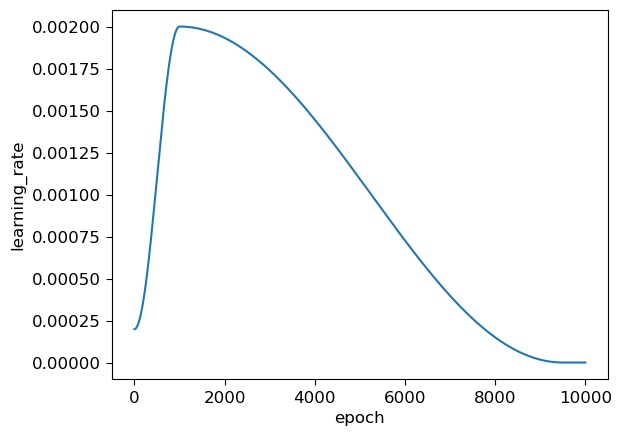

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': stats['learning_rate']})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

In [106]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 

# training parameters
lr_params = {'max_epochs': 5000, 'maximum_learning_rate': 2e-3, 'minimum_learning_rate': 2e-4,
                 'lr_restart_epoch': 1000, 'reset_optimizer_epoch': 200}

other_params = {'batch_size': 256, 
                'network_noise_scale': 10, 
                'gradient_noise_scale': 1e-9}

regularization_params = {'param_lambda_L2': 1e-6, 
                         'discriminator_lambda_L2': 1e-5,
                         'moa_lambda_L1': 0.1, #'ligand_lambda_L2': 1e-5, 
                         'uniform_lambda_L2': 1e-4,  
                         'uniform_max': (1/1.2), 
                         'spectral_loss_factor': 1e-5}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}
target_spectral_radius = 0.8

mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     covariates = subset_tf.obs,
                     categorical_covariate_keys = ['celltype'],
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainCat(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = torch.nn.MSELoss(reduction='mean'),
                   hyper_params = training_params,
                   train_split = {'train': 0.8, 'test': 0.2, 'validation': None}, 
                   train_seed = seed, 
                   track_test = True, 
                  track_validation = False)

In [93]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import pytorch_warmup as warmup

In [107]:
warmup_epochs = 500
self = trainer

In [108]:
prediction_optimizer = torch.optim.Adam

In [118]:
self.prediction_optimizer = prediction_optimizer(self.mod.parameters(), 
                                                 lr=self.hyper_params['minimum_learning_rate'], 
                                                 weight_decay=0)

In [119]:
# warmup_scheduler = warmup.ExponentialWarmup(optimizer = self.prediction_optimizer, warmup_period=warmup_epochs)
# lr_scheduler = CosineAnnealingWarmRestarts(optimizer = self.prediction_optimizer,
#                                            T_0 = self.hyper_params['lr_restart_epoch'],
#                                            eta_min = self.hyper_params['minimum_learning_rate'], 
#                                            last_epoch = -1)

In [120]:
lr_scheduler = ChainedScheduler(optimizer = self.prediction_optimizer,
                                                              T_0 = self.hyper_params['lr_restart_epoch'],
                                                              T_mul = 1, 
                                                              gamma = 1,
                                                              eta_min = self.hyper_params['minimum_learning_rate'],
                                                              max_lr=self.hyper_params['maximum_learning_rate'],
                                                              warmup_steps = 500,
                                                              last_epoch = -1)

In [121]:
# learning_rates = []
# for epoch in range(self.hyper_params['max_epochs']):
#     cur_lr = self.prediction_optimizer.param_groups[0]['lr']
#     learning_rates.append(cur_lr)
    
#     self.prediction_optimizer.step()
#     with warmup_scheduler.dampening():
#         lr_scheduler.step()    
learning_rates = []
lr_2 = []
for epoch in range(self.hyper_params['max_epochs']):
    self.prediction_optimizer.step()
    lr_scheduler.step()
    lr = lr_scheduler.get_lr()[0]
    self.prediction_optimizer.param_groups
    learning_rates.append(lr)
    lr_2.append(self.prediction_optimizer.param_groups[0]['lr'])

In [102]:
np.allclose(learning_rates, lr_2)

True

In [101]:
lr_2[:10]

[0.0002035928143712575,
 0.00020718562874251498,
 0.00021077844311377246,
 0.00021437125748502995,
 0.00021796407185628743,
 0.0002215568862275449,
 0.0002251497005988024,
 0.00022874251497005988,
 0.00023233532934131736,
 0.00023592814371257485]

<Axes: xlabel='epoch', ylabel='learning_rate'>

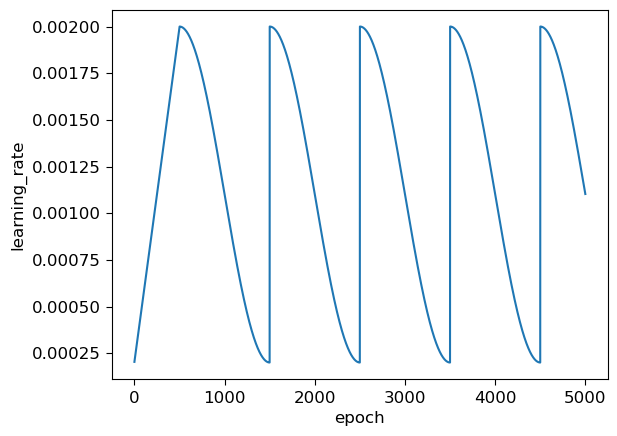

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

<Axes: xlabel='epoch', ylabel='learning_rate'>

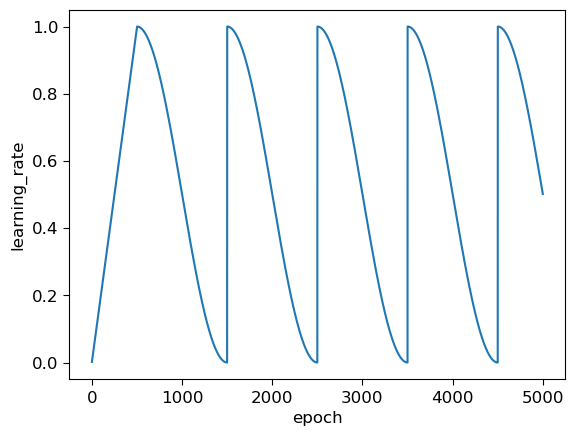

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

In [51]:
lr_scheduler = CosineAnnealingWarmRestarts(optimizer = self.prediction_optimizer,
                                           T_0 = self.hyper_params['lr_restart_epoch'],
                                           eta_min = self.hyper_params['minimum_learning_rate'], 
                                           last_epoch = -1)

In [52]:
learning_rates = []
for epoch in range(self.hyper_params['max_epochs']):
    self.prediction_optimizer.step()
    lr_scheduler.step()
    lr = lr_scheduler.get_lr()[0]
    learning_rates.append(lr)

<Axes: xlabel='epoch', ylabel='learning_rate'>

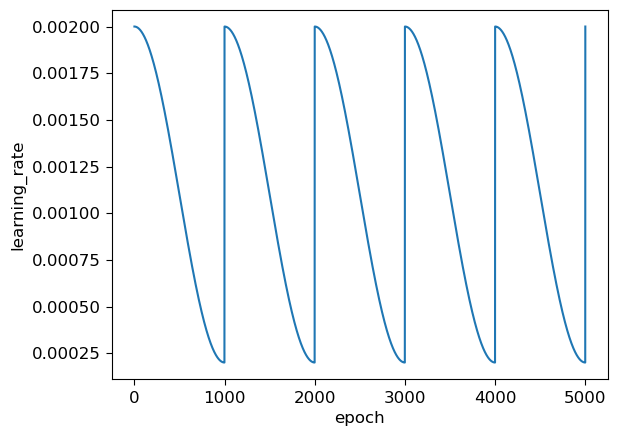

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

In [112]:
from lightning.

<Axes: xlabel='epoch', ylabel='learning_rate'>

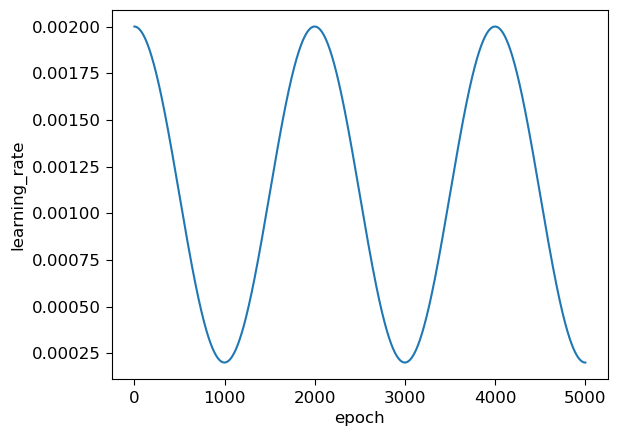

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

<Axes: xlabel='epoch', ylabel='learning_rate'>

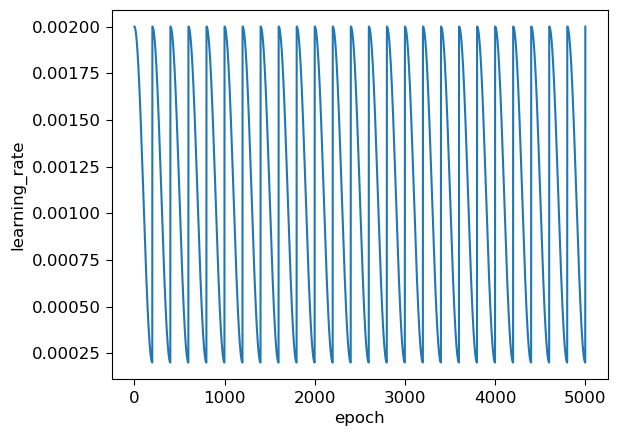

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

<Axes: xlabel='epoch', ylabel='learning_rate'>

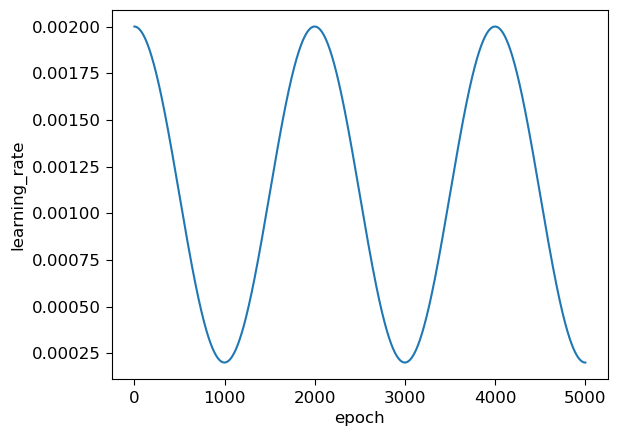

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_df = pd.DataFrame({'learning_rate': learning_rates})
stats_df['epoch'] = stats_df.index + 1
sns.lineplot(stats_df, x = 'epoch', y = 'learning_rate')

# End

Let's see what the output looks like:

In [ ]:
def unique_tol(arr, tol=1e-5, axis=0):
    if axis == 1:
        arr = arr.T
    norm_arr = arr / arr[:, [0]]
    
    # Sort the array based on rows
    sorted_indices = np.lexsort(norm_arr.T)
    sorted_arr = arr[sorted_indices, :]
    
    # Calculate the differences between consecutive rows
    diffs = np.diff(sorted_arr, axis=0)
    
    # Use a norm (e.g., L2 norm) to find row differences, then check against tolerance
    row_diffs = np.linalg.norm(diffs, axis=1)
    unique_row_indices = np.where(row_diffs > tol)[0]
    
    # Add the first row and the rows after significant changes
    unique_indices = np.r_[0, unique_row_indices + 1]
    
    # Select the unique rows
    unique_rows = sorted_arr[unique_indices, :]
    
    if axis == 1:
        unique_rows = unique_rows.T
        
    return unique_rows

We expect 4 unique predictions, one for each ligand/cell type combination:

In [ ]:
covariates_idx = mod.signaling_network.covariates_to_tensor(sample_ids = X_test.index)
X_test_tensor = mod.df_to_tensor(X_test)
y_pred, Y_full = mod(X_test_tensor, covariates_idx)
y_pred = y_pred.cpu().detach().numpy()

y_pred_unique = unique_tol(y_pred, tol = 1e-5, axis = 0)
print('The number of unique predictions across all test data is {}'.format(len(y_pred_unique)))

We can see that there are only 2 unique prediction values, because the model is currently not aware of single-cell resolution (or cell type) data. Let's see what exactly these predicted values are:

In [ ]:
ligand_input[selected_ligand] = pd.Categorical(ligand_input[selected_ligand], 
                                              categories = sorted(ligand_input[selected_ligand].unique()), 
                                              ordered = True)

# get the centroids in the full TF activity space
clf_full = NearestCentroid()
train_cats = subset_tf.obs.loc[y_train.index, ['celltype', selected_ligand]]
train_cats = train_cats.celltype.str.cat(train_cats[selected_ligand].astype(str), sep='_')
clf_full.fit(y_train, train_cats)
train_centroids = pd.DataFrame(clf_full.centroids_ , index = clf_full.classes_, columns = y_train.columns)

# get the predictions for stimulated (1) and unstimulated (0) b/w cell types A and B
test_preds = pd.DataFrame(index = train_centroids.index, columns = train_centroids.columns)
for ct in subset_tf.obs.celltype.unique():
    for ls in subset_tf.obs[selected_ligand].unique():
        cat_idx = subset_tf.obs[(subset_tf.obs.celltype == ct) & (subset_tf.obs[selected_ligand] == ls)].index
        cat_idx = cat_idx[cat_idx.isin(X_test.index)]
        # sample_id = cat_idx[0]
        covariates_idx = mod.signaling_network.covariates_to_tensor(cat_idx)
        X_test_ = mod.df_to_tensor(X_test.loc[cat_idx, :])
        y_pred, Y_full = mod(X_test_, covariates_idx)
        y_pred = unique_tol(y_pred.cpu().detach().numpy(), tol = 1e-5, axis = 0)
        
        test_preds.loc[ct + '_' + str(ls), :] = y_pred

# re-run the PCA on the training subset to visualize/project into this space
tf_adata_train = tf_adata[y_train.index, y_train.columns].copy()
tf_adata_train.obs.drop(columns = ['TF_clusters'], inplace = True)
tf_adata_train = embed_tf_activity(tf_adata_train, estimate_key = None, scanpy_pca = False)
tf_adata_train.TF_clusters = tf_adata[y_train.index, y_train.columns].obs.TF_clusters # replace with original clusters
pca = tf_adata_train.uns['pca']['pca_mod']

# get the train dataset centroids as well as project the predictions into pca space 
train_pca_centroids = pca.transform(train_centroids)
pred_pca_centroids = pca.transform(test_preds.values)

In [ ]:
viz_adata_ = viz_adata.copy()
viz_adata_ = viz_adata_[tf_adata_train.obs.index, ]
viz_adata_.obs['Condition'] = viz_adata_.obs.celltype.str.cat(viz_adata_.obs[selected_ligand].astype(str), sep='_')
train_cats = viz_adata_.obs.copy()

In [ ]:
w, h = 5,4
p1 = plot_embedding(adata = viz_adata_, group_label = 'Condition', embedding = 'pca', 
                    palette = 'Set2', width = w, height = h, size = 0.5)
p1 + p9.theme(figure_size=(w, h))

In [ ]:
# train_pc_rank = tf_adata_train.uns['pca']['pca_rank']
# y_train_eds_full = list()
# y_train_eds_reduced = list()
# for idx in y_train.index:
#     # full TF space
#     y_vals = y_train.loc[idx, :]
#     pred_type = train_cats.loc[idx, 'Condition']
#     y_centroid = train_centroids.loc[pred_type, :]

#     ed = np.linalg.norm(y_vals - y_centroid)
#     y_train_eds_full.append(ed)

#     # reduced space
#     y_vals = tf_adata_train.obsm['X_pca'][tf_adata_train.obs.index.tolist().index(idx),:][:train_pc_rank]
#     y_centroid = train_pca_centroids[train_centroids.index.tolist().index(pred_type), :][:train_pc_rank]

#     ed = np.linalg.norm(y_vals - y_centroid)
#     y_train_eds_reduced.append(ed)   
    
# fig, ax = plt.subplots(figsize = (12,3), ncols = 2)

# colors = sns.color_palette('Set1')

# sns.kdeplot(y_train_eds_full, ax = ax[0], color = colors[0])
# # children = plt.gca().get_children()
# l0 = ax[0].vlines(np.linalg.norm(y_pred_0 - train_centroids.loc[0,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[1])
# l1 = ax[0].vlines(np.linalg.norm(y_pred_1 - train_centroids.loc[1,:].values), ymin = 0, ymax = 0.95*ax[0].get_ylim()[1], color = colors[2])
# ax[0].set_xlabel('Euclidean Distance to Training Centroid')
# ax[0].set_title('Full TF Activity Space')

# sns.kdeplot(y_train_eds_reduced, ax = ax[1], color = colors[0])
# children = plt.gca().get_children()
# l0 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[0,:train_pc_rank] - train_pca_centroids[0,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[1])
# l1 = ax[1].vlines(np.linalg.norm(pred_pca_centroids[1,:train_pc_rank] - train_pca_centroids[1,:train_pc_rank]), ymin = 0, ymax = 0.95*ax[1].get_ylim()[1], color = colors[2])
# ax[1].set_xlabel('Euclidean Distance to Training Centroid')
# ax[1].set_title('Reduced TF Activity Space ({} PCs)'.format(train_pc_rank))

# plt.legend([children[0], l0, l1], ['Training Data', 'Prediction: Unstimulated', 'Prediction: Stimulated'], 
#           bbox_to_anchor=(1, 1.05))
# fig.tight_layout()

In [ ]:
tf_adata_train.obs['Condition'] = viz_adata_.obs['Condition']

# training data
X_train = tf_adata_train.obsm['X_pca']
X_train = pd.DataFrame(tf_adata_train.obsm['X_pca'][:, :2], index = tf_adata_train.obs.index, 
                         columns = ['PC_' + str(i+1) for i in range(2)])
col_labels = [' '.join(i.split('_')) for i in X_train.columns]
X_train = pd.concat([X_train, tf_adata_train.obs.Condition], axis = 1)

In [ ]:
width, height = 5, 3
set1_colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#FFFF33', '#A65628']



tf_adata_train.obs['Condition'] = viz_adata_.obs['Condition']

# training data
X_train = tf_adata_train.obsm['X_pca']
X_train = pd.DataFrame(tf_adata_train.obsm['X_pca'][:, :2], index = tf_adata_train.obs.index, 
                         columns = ['PC_' + str(i+1) for i in range(2)])
col_labels = [' '.join(i.split('_')) for i in X_train.columns]
X_train = pd.concat([X_train, tf_adata_train.obs.Condition], axis = 1)

# centroids and predicted values
X_centroids = pd.DataFrame(train_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])
X_pred = pd.DataFrame(pred_pca_centroids[:, :2], index = clf_full.classes_, 
                     columns = ['PC_' + str(i+1) for i in range(2)])

p3 = (
    p9.ggplot() +
    p9.geom_point(X_train, p9.aes(x=X_train.columns[0], y = X_train.columns[1], color = 'Condition'), 
                 size = 0.1) +
    p9.scale_color_manual(values=set1_colors) +
    p9.geom_point(X_centroids, p9.aes(x=X_centroids.columns[0], y = X_centroids.columns[1]), shape = 'X', color = 'black') +
    p9.geom_point(X_pred, p9.aes(x=X_pred.columns[0], y = X_pred.columns[1]), shape = '*', color = 'blue') +
    p9.xlab(col_labels[0]) + p9.ylab(col_labels[1]) + 
    p9.theme_bw() + p9.theme(figure_size=(width, height))  
    
)
p3